## Part 1

#### Subpart 1

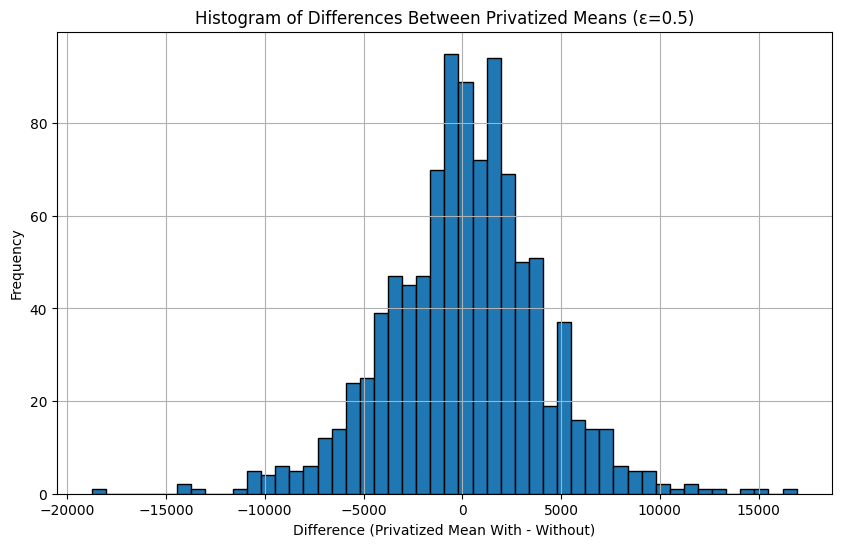

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data with and without the individual
data_with = [50_000, 52_000, 47_000, 49_000, 51_000]
data_without = [52_000, 47_000, 49_000, 51_000]

# Privacy parameter
epsilon = 0.5

# Sensitivity of average function
sensitivity = (max(data_with) - min(data_with)) / len(data_with)

# Laplace mechanism: adds noise to privatize mean
def laplace_mechanism(value, sensitivity, epsilon):
    scale = sensitivity / epsilon
    noise = np.random.laplace(0, scale)
    return value + noise

# Run 1000 experiments
diffs = []

for _ in range(1000):
    mean_with = np.mean(data_with)
    mean_without = np.mean(data_without)

    priv_mean_with = laplace_mechanism(mean_with, sensitivity, epsilon)
    priv_mean_without = laplace_mechanism(mean_without, sensitivity, epsilon)

    diff = priv_mean_with - priv_mean_without
    diffs.append(diff)

# Plot histogram of differences
plt.figure(figsize=(10, 6))
plt.hist(diffs, bins=50, edgecolor='black')
plt.title("Histogram of Differences Between Privatized Means (ε=0.5)")
plt.xlabel("Difference (Privatized Mean With - Without)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


#### Subpart 2

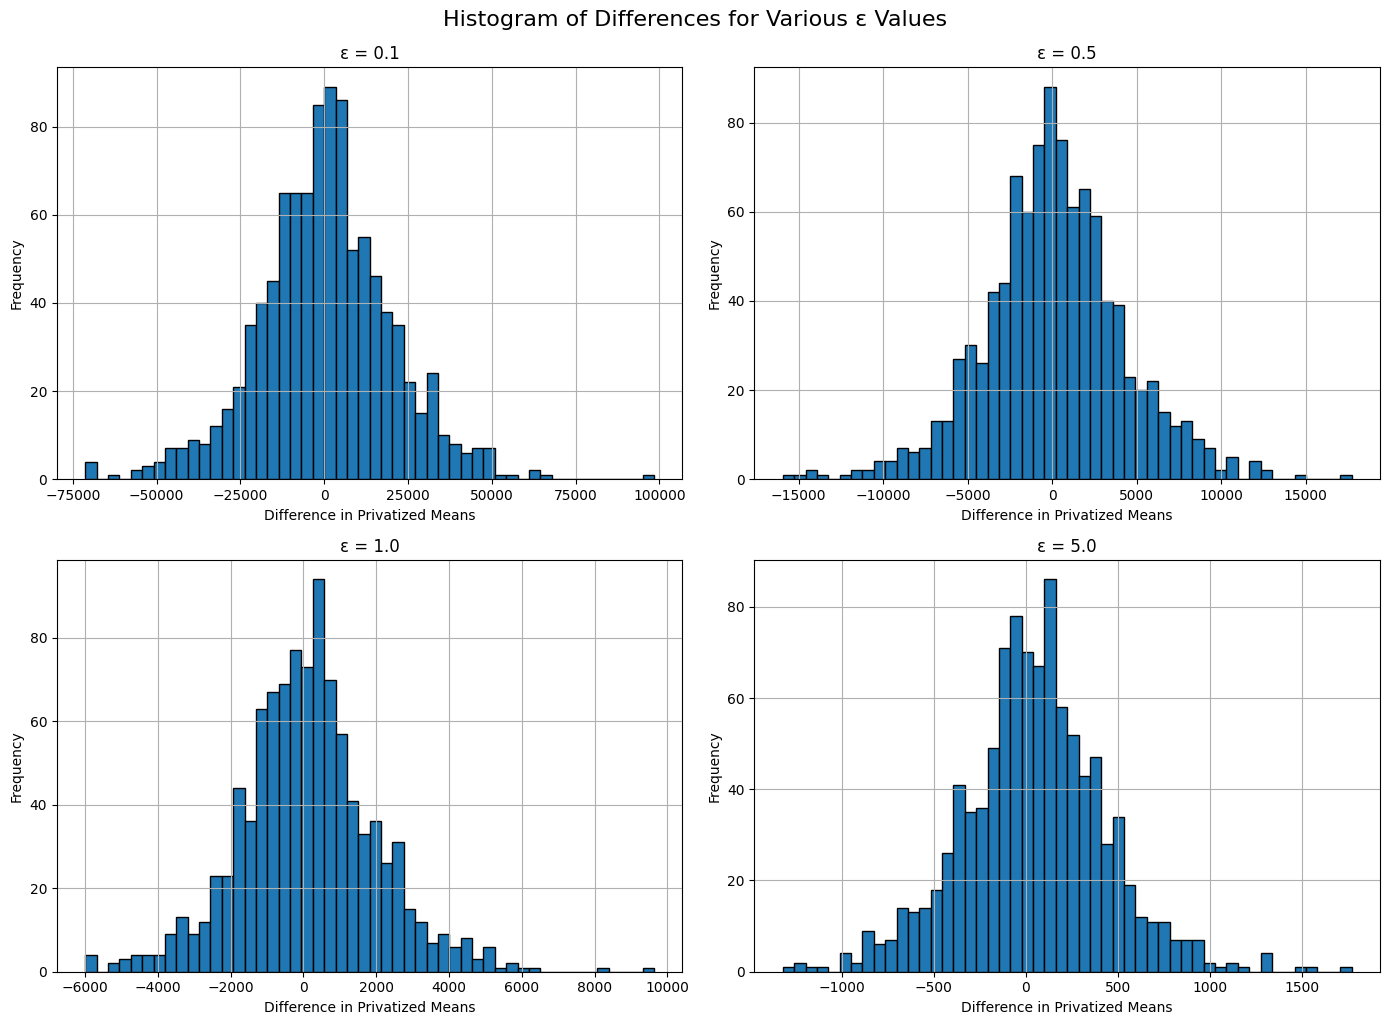

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Original datasets
data_with = [50_000, 52_000, 47_000, 49_000, 51_000]
data_without = [52_000, 47_000, 49_000, 51_000]

# Different epsilon values
epsilon_values = [0.1, 0.5, 1.0, 5.0]

# Sensitivity of the mean
sensitivity = (max(data_with) - min(data_with)) / len(data_with)

# Laplace mechanism
def laplace_mechanism(value, sensitivity, epsilon):
    scale = sensitivity / epsilon
    noise = np.random.laplace(0, scale)
    return value + noise

# Run the experiment for each epsilon
num_trials = 1000
results = {}

for epsilon in epsilon_values:
    diffs = []
    for _ in range(num_trials):
        mean_with = np.mean(data_with)
        mean_without = np.mean(data_without)

        priv_mean_with = laplace_mechanism(mean_with, sensitivity, epsilon)
        priv_mean_without = laplace_mechanism(mean_without, sensitivity, epsilon)

        diff = priv_mean_with - priv_mean_without
        diffs.append(diff)

    results[epsilon] = diffs

# Plotting
plt.figure(figsize=(14, 10))

for i, epsilon in enumerate(epsilon_values, 1):
    plt.subplot(2, 2, i)
    plt.hist(results[epsilon], bins=50, edgecolor='black')
    plt.title(f"ε = {epsilon}")
    plt.xlabel("Difference in Privatized Means")
    plt.ylabel("Frequency")
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Histogram of Differences for Various ε Values", fontsize=16, y=1.02)
plt.show()


#### Subpart 3

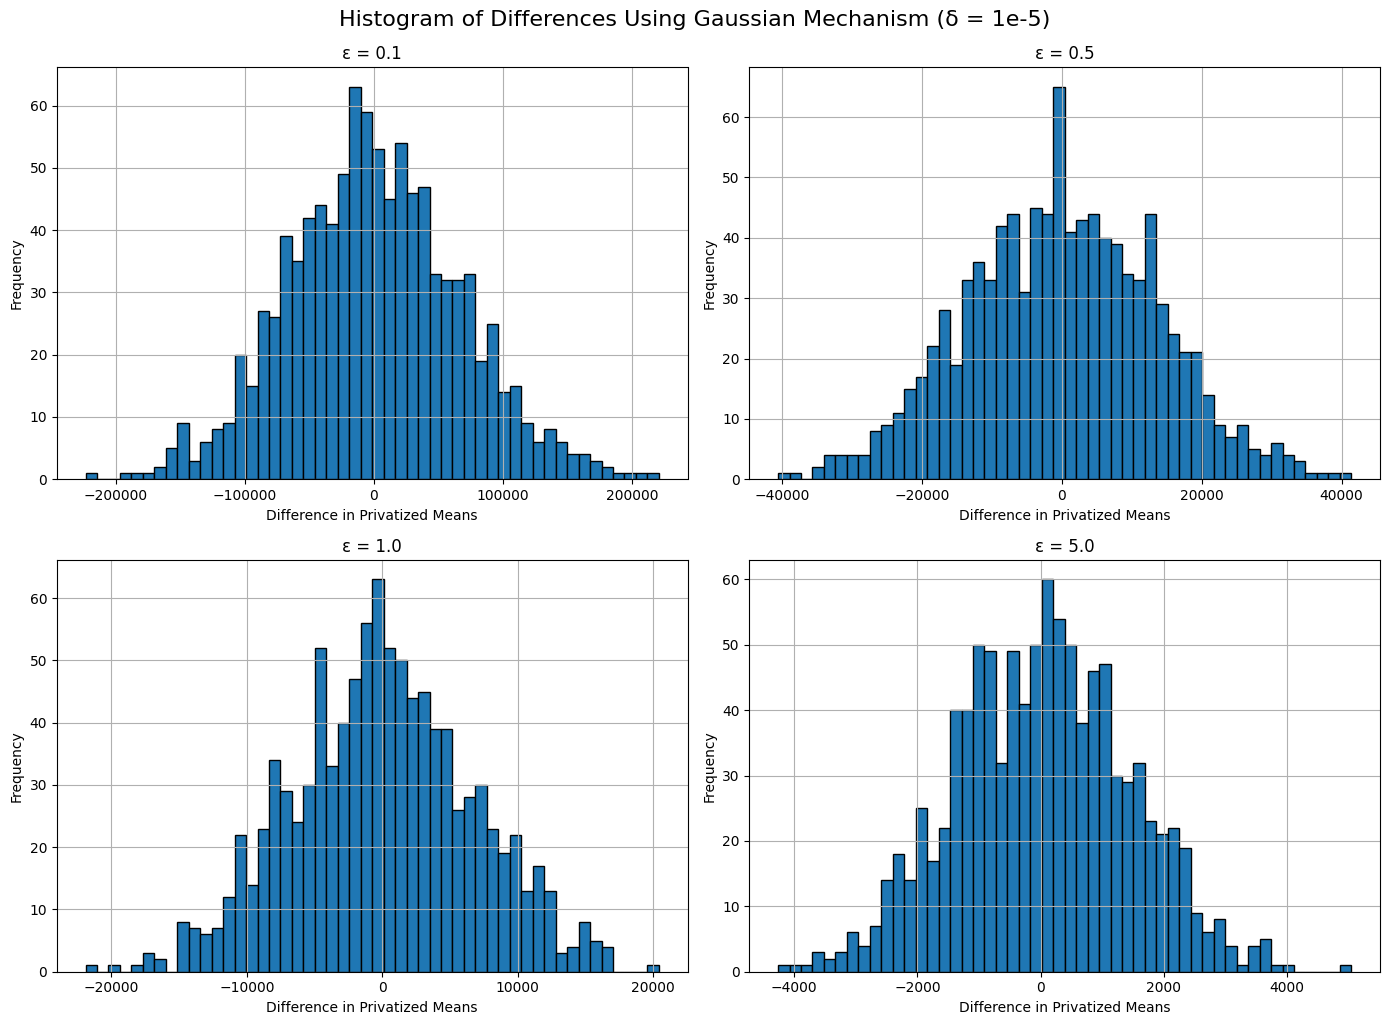

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Data
data_with = [50_000, 52_000, 47_000, 49_000, 51_000]
data_without = [52_000, 47_000, 49_000, 51_000]

# Epsilon values and fixed delta
epsilon_values = [0.1, 0.5, 1.0, 5.0]
delta = 1e-5

# Sensitivity for average
sensitivity = (max(data_with) - min(data_with)) / len(data_with)

# Gaussian mechanism
def gaussian_mechanism(value, sensitivity, epsilon, delta):
    sigma = np.sqrt(2 * np.log(1.25 / delta)) * (sensitivity / epsilon)
    noise = np.random.normal(0, sigma)
    return value + noise

# Run experiment
num_trials = 1000
results = {}

for epsilon in epsilon_values:
    diffs = []
    for _ in range(num_trials):
        mean_with = np.mean(data_with)
        mean_without = np.mean(data_without)

        priv_mean_with = gaussian_mechanism(mean_with, sensitivity, epsilon, delta)
        priv_mean_without = gaussian_mechanism(mean_without, sensitivity, epsilon, delta)

        diff = priv_mean_with - priv_mean_without
        diffs.append(diff)

    results[epsilon] = diffs

# Plotting
plt.figure(figsize=(14, 10))

for i, epsilon in enumerate(epsilon_values, 1):
    plt.subplot(2, 2, i)
    plt.hist(results[epsilon], bins=50, edgecolor='black')
    plt.title(f"ε = {epsilon}")
    plt.xlabel("Difference in Privatized Means")
    plt.ylabel("Frequency")
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Histogram of Differences Using Gaussian Mechanism (δ = 1e-5)", fontsize=16, y=1.02)
plt.show()


## Part 2

#### Subpart 1

In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Step 1: Generate synthetic data
np.random.seed(42)
n_samples = 100
X = np.random.rand(n_samples, 2) * 10
true_weights = np.array([2.0, -3.5])
y = X @ true_weights + np.random.randn(n_samples) * 2.0  # add small noise

# Step 2: Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Print weights and compute MSE
print("Learned Weights:", model.coef_)
print("Intercept:", model.intercept_)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Test Mean Squared Error (MSE):", mse)


Learned Weights: [ 2.05090271 -3.40516802]
Intercept: -0.5666570012206149
Test Mean Squared Error (MSE): 2.8577935745975207


#### Subpart 2

In [5]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Step 1: Generate synthetic data
np.random.seed(42)
n_samples = 100
X = np.random.rand(n_samples, 2) * 10
true_weights = np.array([2.0, -3.5])
y = X @ true_weights + np.random.randn(n_samples) * 2.0

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Original model predictions and MSE
original_pred = model.predict(X_test)
original_mse = mean_squared_error(y_test, original_pred)

print("Original Weights:", model.coef_)
print("Original Intercept:", model.intercept_)
print("Original Test MSE:", original_mse)

# Step 4: Gaussian Mechanism
def gaussian_mechanism(weights, epsilon, delta, sensitivity):
    sigma = np.sqrt(2 * np.log(1.25 / delta)) * (sensitivity / epsilon)
    noise = np.random.normal(0, sigma, size=weights.shape)
    return weights + noise

# Parameters for DP
epsilon = 1.0
delta = 1e-5
sensitivity = 0.05  # given

# Step 5: Add noise to weights
noisy_weights = gaussian_mechanism(model.coef_, epsilon, delta, sensitivity)
noisy_intercept = model.intercept_  # we leave intercept unchanged for simplicity

# Step 6: Use noisy weights for prediction
y_pred_private = X_test @ noisy_weights + noisy_intercept
private_mse = mean_squared_error(y_test, y_pred_private)

print("\nPrivate Weights:", noisy_weights)
print("Private Test MSE:", private_mse)


Original Weights: [ 2.05090271 -3.40516802]
Original Intercept: -0.5666570012206149
Original Test MSE: 2.8577935745975207

Private Weights: [ 2.56497439 -3.15506336]
Private Test MSE: 14.339714226858987


#### Subpart 3

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd

# Step 1: Generate synthetic data
np.random.seed(42)
n_samples = 100
X = np.random.rand(n_samples, 2) * 10
true_weights = np.array([2.0, -3.5])
y = X @ true_weights + np.random.randn(n_samples) * 2.0

# Step 2: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train baseline model
model = LinearRegression()
model.fit(X_train, y_train)

# Original model MSE
original_pred = model.predict(X_test)
original_mse = mean_squared_error(y_test, original_pred)

# Step 4: Gaussian mechanism
def gaussian_mechanism(weights, epsilon, delta, sensitivity):
    sigma = np.sqrt(2 * np.log(1.25 / delta)) * (sensitivity / epsilon)
    noise = np.random.normal(0, sigma, size=weights.shape)
    return weights + noise

# Step 5: Run experiment for different ε values
epsilons = [0.1, 0.5, 1.0, 5.0]
delta = 1e-5
sensitivity = 0.05

results = []

for epsilon in epsilons:
    noisy_weights = gaussian_mechanism(model.coef_, epsilon, delta, sensitivity)
    noisy_intercept = model.intercept_  # (or add noise here too)

    # Predict with private weights
    y_pred_private = X_test @ noisy_weights + noisy_intercept
    private_mse = mean_squared_error(y_test, y_pred_private)

    results.append({
        "ε": epsilon,
        "MSE (Private Model)": private_mse
    })

# Step 6: Display results
df_results = pd.DataFrame(results)
print("Original (Non-private) MSE:", original_mse)
print("\nPrivate Model Performance for Various ε:\n")
print(df_results.to_string(index=False))


Original (Non-private) MSE: 2.8577935745975207

Private Model Performance for Various ε:

  ε  MSE (Private Model)
0.1          1434.720316
0.5            31.447417
1.0             3.024563
5.0             2.765135


#### Subpart 4

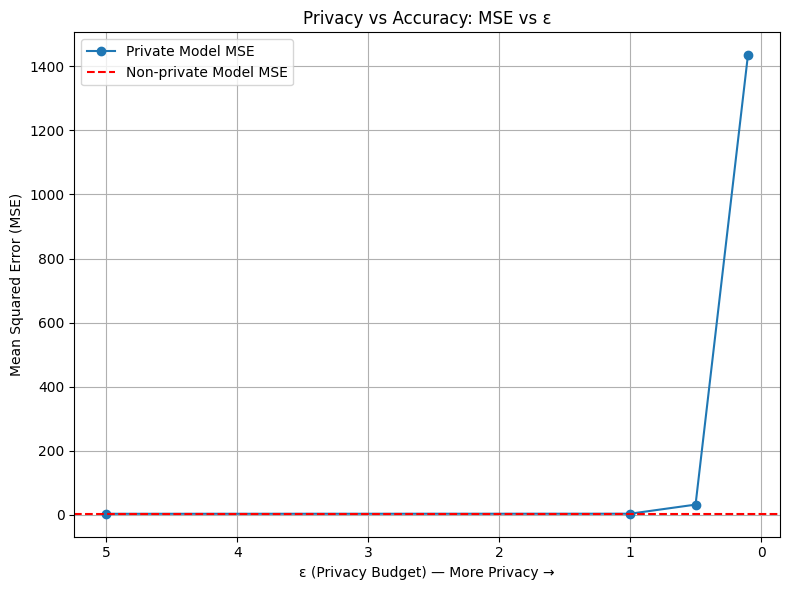

In [7]:
import matplotlib.pyplot as plt

# Extract values for plotting
eps_vals = df_results["ε"].values
mse_vals = df_results["MSE (Private Model)"].values

# Plot
plt.figure(figsize=(8, 6))
plt.plot(eps_vals, mse_vals, marker='o', label='Private Model MSE')
plt.axhline(y=original_mse, color='red', linestyle='--', label='Non-private Model MSE')

# Reverse x-axis: higher privacy (lower ε) on the right
plt.gca().invert_xaxis()

# Labels and title
plt.xlabel("ε (Privacy Budget) — More Privacy →")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Privacy vs Accuracy: MSE vs ε")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Part 3

### SubPart 1

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [17]:
# Step 1: Load the dataset
df = pd.read_csv("/kaggle/diabetes.csv")

# Step 2: Separate features and labels
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Step 3: Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Split the data (stratify to preserve class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Train standard Logistic Regression (no DP)
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 6: Evaluate performance
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))

print("Logistic Regression (No DP):")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")


Logistic Regression (No DP):
Train Accuracy: 0.7915
Test Accuracy:  0.7143


### SubPart 2

In [19]:
!pip install diffprivlib

  Using cached diffprivlib-0.6.6-py3-none-any.whl.metadata (10 kB)
Using cached diffprivlib-0.6.6-py3-none-any.whl (176 kB)


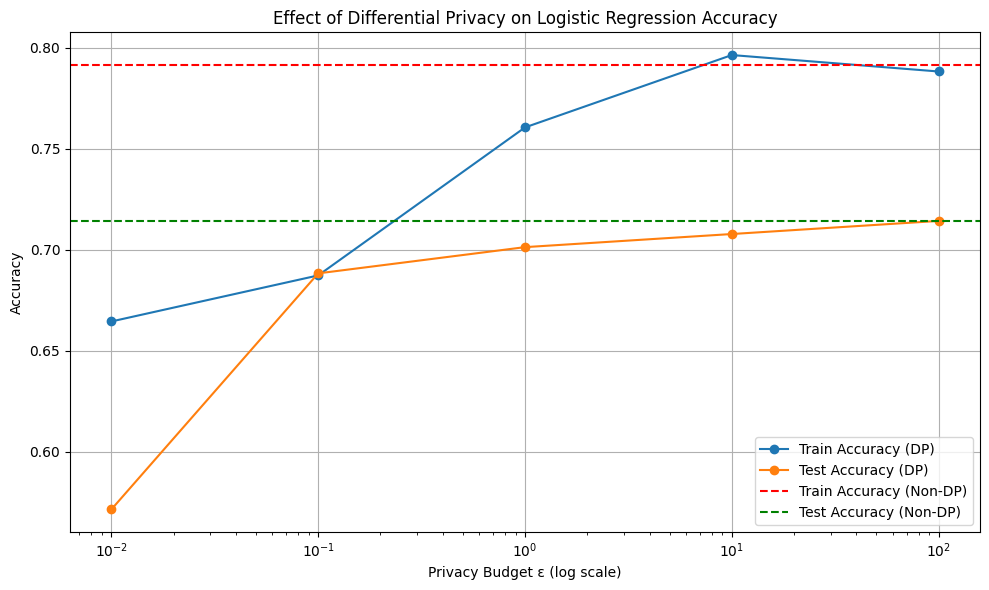

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from diffprivlib.models import LogisticRegression as DPLogisticRegression

# Load dataset
df = pd.read_csv("/kaggle/diabetes.csv")
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Train non-private model for reference
non_private_model = SklearnLogisticRegression()
non_private_model.fit(X_train, y_train)
non_private_train_acc = accuracy_score(y_train, non_private_model.predict(X_train))
non_private_test_acc = accuracy_score(y_test, non_private_model.predict(X_test))

# Run DP Logistic Regression for different epsilons
epsilons = [0.01, 0.1, 1, 10, 100]
dp_train_accs = []
dp_test_accs = []

for eps in epsilons:
    dp_model = DPLogisticRegression(epsilon=eps, data_norm=5)
    dp_model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, dp_model.predict(X_train))
    test_acc = accuracy_score(y_test, dp_model.predict(X_test))

    dp_train_accs.append(train_acc)
    dp_test_accs.append(test_acc)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(epsilons, dp_train_accs, marker='o', label="Train Accuracy (DP)")
plt.plot(epsilons, dp_test_accs, marker='o', label="Test Accuracy (DP)")
plt.axhline(non_private_train_acc, color='red', linestyle='--', label="Train Accuracy (Non-DP)")
plt.axhline(non_private_test_acc, color='green', linestyle='--', label="Test Accuracy (Non-DP)")

plt.xscale('log')
plt.xlabel("Privacy Budget ε (log scale)")
plt.ylabel("Accuracy")
plt.title("Effect of Differential Privacy on Logistic Regression Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### SubPart 3

/usr/local/lib/python3.11/dist-packages/diffprivlib/models/naive_bayes.py:114: PrivacyLeakWarning: Bounds have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify bounds for each dimension.
  warnings.warn("Bounds have not been specified and will be calculated on the data provided. This will "
/usr/local/lib/python3.11/dist-packages/diffprivlib/models/naive_bayes.py:114: PrivacyLeakWarning: Bounds have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify bounds for each dimension.
  warnings.warn("Bounds have not been specified and will be calculated on the data provided. This will "
/usr/local/lib/python3.11/dist-packages/diffprivlib/models/naive_bayes.py:114: PrivacyLeakWarning: Bounds have not been specified and will be 

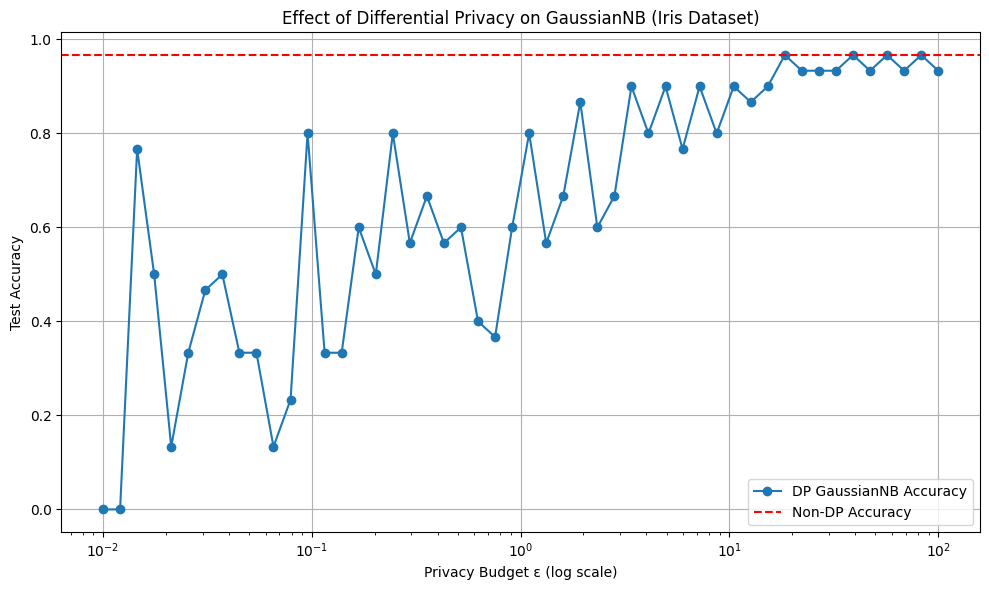

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB as SklearnGaussianNB
from sklearn.metrics import accuracy_score
from diffprivlib.models import GaussianNB as DPGaussianNB

# Step 1: Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 3: Non-private model
non_dp_model = SklearnGaussianNB()
non_dp_model.fit(X_train, y_train)
non_dp_acc = accuracy_score(y_test, non_dp_model.predict(X_test))

# Step 4: Private model for various ε
epsilons = np.logspace(-2, 2, 50)  # ε values from 0.01 to 100
dp_accuracies = []

for eps in epsilons:
    dp_model = DPGaussianNB(epsilon=eps)
    dp_model.fit(X_train, y_train)
    acc = accuracy_score(y_test, dp_model.predict(X_test))
    dp_accuracies.append(acc)

# Step 5: Plot
plt.figure(figsize=(10, 6))
plt.semilogx(epsilons, dp_accuracies, marker='o', label="DP GaussianNB Accuracy")
plt.axhline(y=non_dp_acc, color='red', linestyle='--', label="Non-DP Accuracy")

plt.xlabel("Privacy Budget ε (log scale)")
plt.ylabel("Test Accuracy")
plt.title("Effect of Differential Privacy on GaussianNB (Iris Dataset)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
